# VISUALIZATION

In [2]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load Data

df = pd.read_csv('cleaned_data.csv')
rfm = pd.read_csv('rfm_analysis.csv')

In [4]:
df.head()

,order_id,customer_id,order_date,status,month,day,country,signup_date,product_id,quantity,price,product_name,category,revenue
0,1,103,2024-10-31,Completed,October,Thursday,Italy,2023-03-22,13.0,4,58.0,Product_13,Skin,232.0
1,3,107,2024-05-23,Completed,May,Thursday,Italy,2024-01-05,18.0,1,25.0,Product_18,Makeup,25.0
2,3,107,2024-05-23,Completed,May,Thursday,Italy,2024-01-05,24.0,4,41.0,Product_24,Hair,164.0
3,3,107,2024-05-23,Completed,May,Thursday,Italy,2024-01-05,42.0,2,66.0,Product_42,Skin,132.0
4,3,107,2024-05-23,Completed,May,Thursday,Italy,2024-01-05,35.0,5,74.0,Product_35,Skin,370.0


In [5]:
rfm.head()

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churn,Cluster
0,1,9,8,2632.0,5,5,5,555,Champion,0,1
1,2,102,3,2075.0,2,3,4,234,Regular,1,2
2,3,40,1,180.0,4,1,1,411,Regular,0,0
3,4,81,4,774.0,3,4,2,342,Loyal,0,2
4,5,36,7,3014.0,4,5,5,455,Loyal,0,1


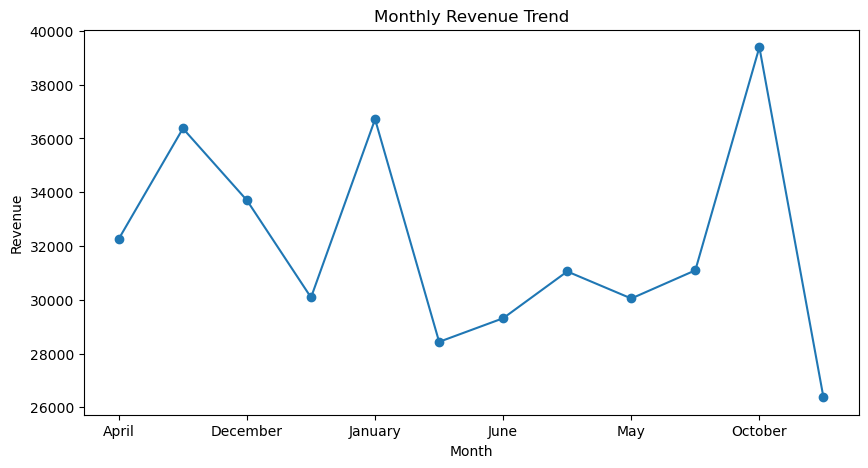

In [6]:
# Sales Trend

monthly_sales = (
    df.groupby('month')['revenue']
    .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

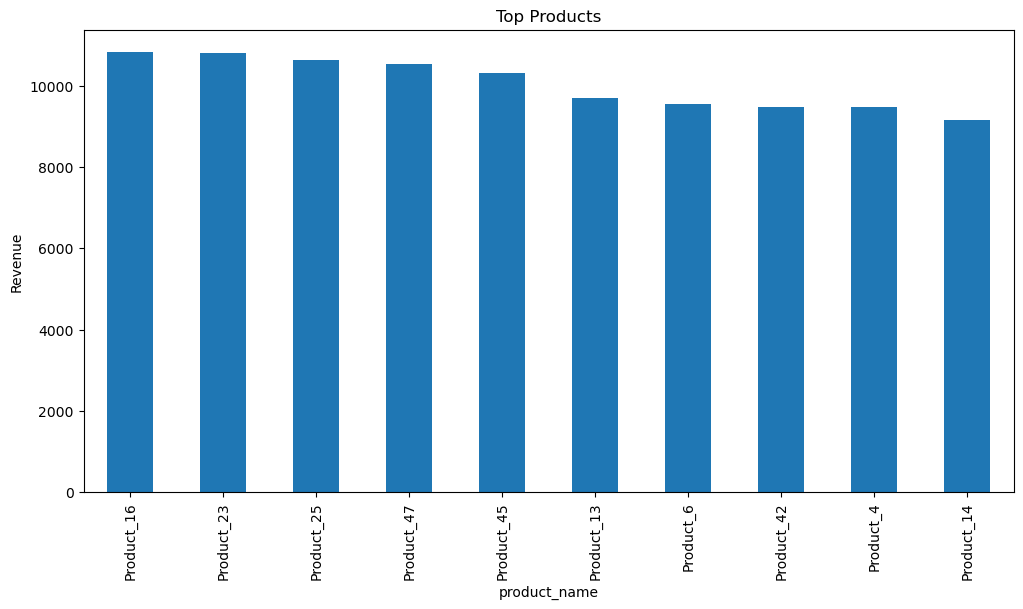

In [8]:
# Top products

top_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top Products")

plt.ylabel("Revenue")

plt.show()

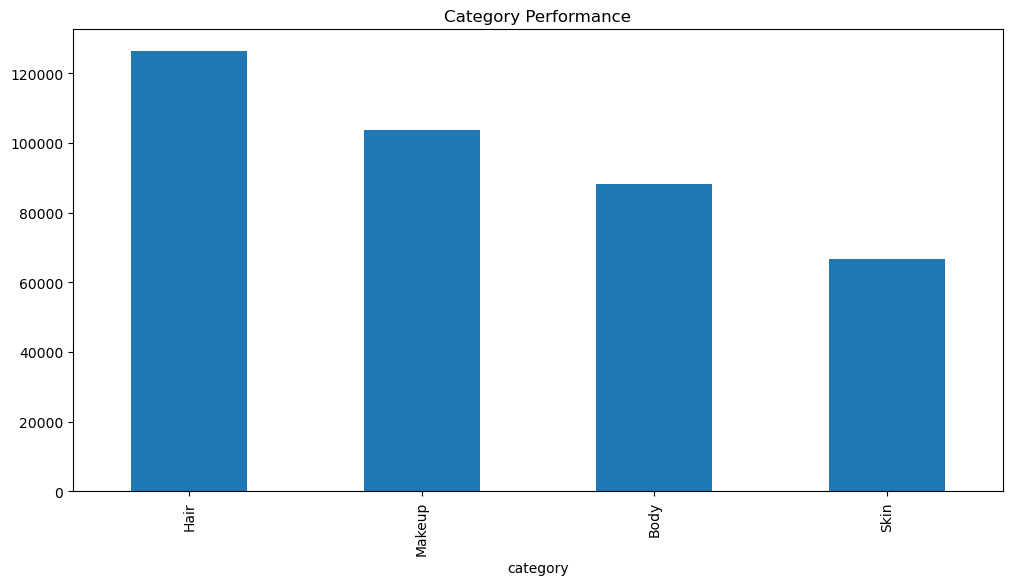

In [10]:
# Category Sales 

category_sales = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

category_sales.plot(kind='bar')

plt.title("Category Performance")

plt.show()


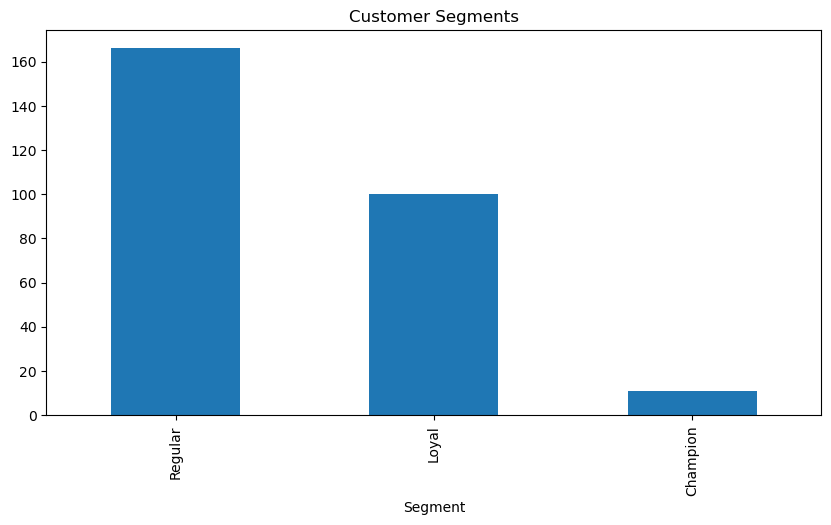

In [11]:
# Customer Segments

plt.figure(figsize=(10,5))

rfm['Segment'].value_counts().plot(
    kind='bar'
)

plt.title("Customer Segments")

plt.show()

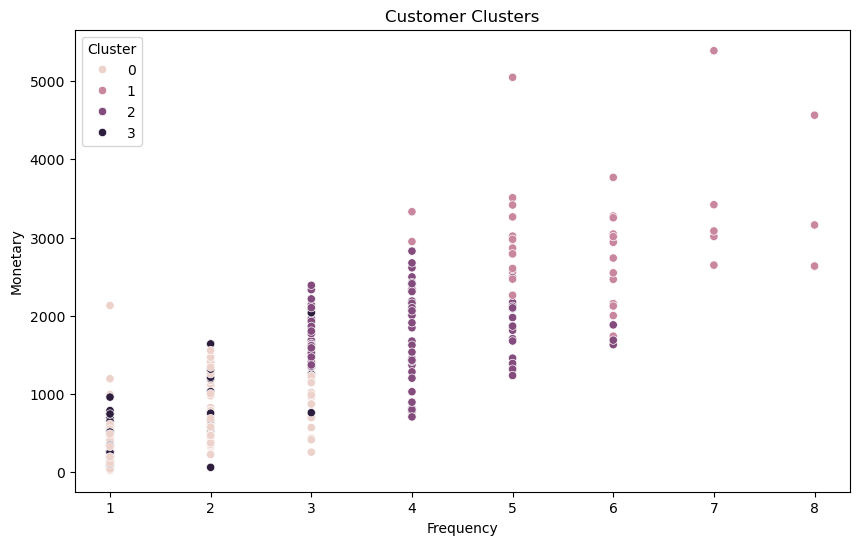

In [12]:
# Cluster Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rfm['Frequency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster']
)

plt.title("Customer Clusters")

plt.show()

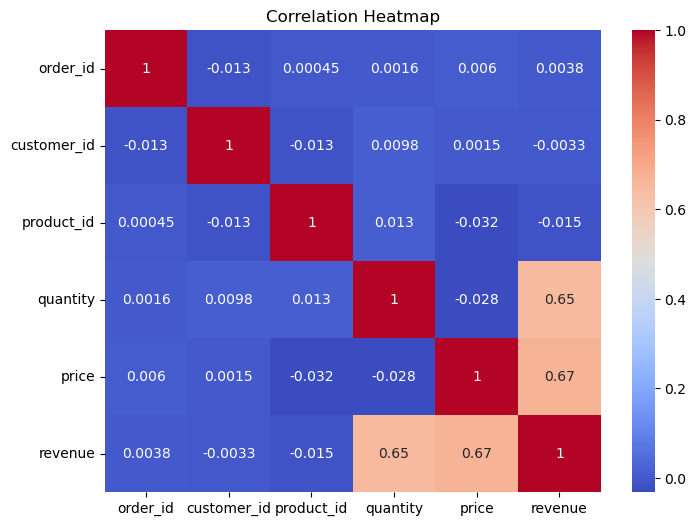

In [13]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### INSIGHTS:-

#### 1. High-frequency customers contribute most revenue.
#### 2. Some categories generate high sales but low repeat purchases.
#### 3. Loyal customers are key revenue drivers.
#### 4. Seasonal sales spikes exist in specific months.
#### 5. At-risk customers may require retention campaigns.